# 09 — Advanced ML Pipeline
## AutoML → Imbalance Handling → Feature Engineering → Feature Selection → GridSearch Fine-Tuning

**Pipeline stages:**
1. **Setup & Data Loading** — raw bank-additional-full.csv, Set B (no `duration`)
2. **Missing Data Inspection & Imputation** — detect unknowns, apply KNN / median imputation
3. **Discretization** — bin continuous features (age, campaign, nr.employed) into meaningful bands
4. **FLAML AutoML** — 300 s budget, all estimators, find top-3 model families
5. **Class Imbalance Handling** — test SMOTE / SMOTETomek / RandomOver on AutoML best models
6. **Feature Selection** — RFECV, SelectFromModel (LightGBM), mutual information ranking
7. **GridSearchCV Fine-Tuning** — exhaustive search on the top-3 AutoML models
8. **Final Comparison** — PR curves, ROC curves, summary table, save champion model

Primary metric: **Accuracy** (business-interpretable) | Secondary: PR-AUC, ROC-AUC | `duration` excluded | `random_state=42`

## 1 — Setup & Data Loading

In [22]:
import sys, warnings, time
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10})
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.base import clone
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, KBinsDiscretizer, LabelEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import (
    SelectFromModel, RFECV, mutual_info_classif, SelectKBest
)
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, auc,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)

from src.data_loader import load_dataset
from src.features import encode_target, add_features, get_feature_lists
from src.preprocessing import build_preprocessing_pipeline, split_data
from src.imbalance import build_imbalanced_pipeline, compare_resampling_strategies

RAW_DIR     = PROJECT_ROOT / "data" / "raw"
MODELS_DIR  = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
CV_FOLDS    = 5
TARGET_COL  = "y"

# ── Load raw & encoded DataFrames ────────────────────────────────────────────
df_raw = pd.read_csv(RAW_DIR / "bank-additional-full.csv", sep=";")
df = load_dataset(RAW_DIR / "bank-additional-full.csv")
df = encode_target(df, TARGET_COL)
df = add_features(df)

lists_b = get_feature_lists(df, exclude_duration=True)
NUMERIC_COLS = lists_b["numeric"]
CAT_COLS     = lists_b["categorical"]
ALL_FEATURES = NUMERIC_COLS + CAT_COLS

X_train, X_test, y_train, y_test = split_data(df, TARGET_COL, random_state=RANDOM_SEED)
X_train_b = X_train[ALL_FEATURES]
X_test_b  = X_test[ALL_FEATURES]

pos_rate = y_train.mean()
print(f"Train {X_train_b.shape}  |  Test {X_test_b.shape}  |  Positive rate {pos_rate:.3f}")

print(f"Numeric features  ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"Categorical features ({len(CAT_COLS)}): {CAT_COLS}")

2026-05-17 13:16:02 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)
2026-05-17 13:16:02 | INFO     | src.features | Encoded target 'y' → 0/1 (41188 rows).
2026-05-17 13:16:02 | INFO     | src.features | add_features: added 9 engineered features.
2026-05-17 13:16:02 | INFO     | src.preprocessing | split_data: train=32950, test=8238 (stratified, test_size=20%)


Train (32950, 28)  |  Test (8238, 28)  |  Positive rate 0.113
Numeric features  (16): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_previously_contacted', 'economic_stress_index', 'month_order', 'previous_contact_success_flag', 'contact_is_cellular', 'client_financial_pressure_flag', 'has_any_loan']
Categorical features (12): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'campaign_intensity_group', 'age_group']


## 2 — Missing Data Inspection & Imputation

The dataset uses `"unknown"` as a placeholder. We convert these to `NaN` on a copy, assess missingness, then apply **median imputation** for numeric and **most-frequent (mode) imputation** for categorical columns before building the final pipeline.

In [23]:
# ── Assess unknowns in raw data (original cols only) ─────────────────────────
raw_cols_in_features = [c for c in ALL_FEATURES if c in df_raw.columns]
unknown_counts = (df_raw[raw_cols_in_features] == "unknown").sum()
unknown_df = unknown_counts[unknown_counts > 0].rename("unknown_count").to_frame()
unknown_df["pct"] = (unknown_df["unknown_count"] / len(df_raw) * 100).round(2)
print("'unknown' placeholder by feature (original raw columns):")
display(unknown_df)

# ── Strategy per column ───────────────────────────────────────────────────────
# Numeric cols: no 'unknown'; NaN → median imputation
# Categorical cols with 'unknown': treat as own category (already handled by OHE)
# Columns with > 5% unknowns: add explicit imputation step
HIGH_UNKNOWN_COLS = unknown_df[unknown_df["pct"] > 5].index.tolist()
print(f"\nHigh-unknown columns (>5%): {HIGH_UNKNOWN_COLS}")
print("Strategy: 'unknown' kept as a valid category; OHE handle_unknown='ignore' covers inference.")

'unknown' placeholder by feature (original raw columns):


,unknown_count,pct
job,330,0.80
marital,80,0.19
education,1731,4.20
default,8597,20.87
housing,990,2.40
loan,990,2.40



High-unknown columns (>5%): ['default']
Strategy: 'unknown' kept as a valid category; OHE handle_unknown='ignore' covers inference.


## 3 — Feature Discretization

We bin three highly skewed continuous features into interpretable categories:
- **`age`** → `young/middle/senior/elderly`
- **`campaign`** → `1 / 2-3 / 4-6 / 7+` contacts
- **`nr.employed`** → Low / Medium / High employment (macro-economic bands)

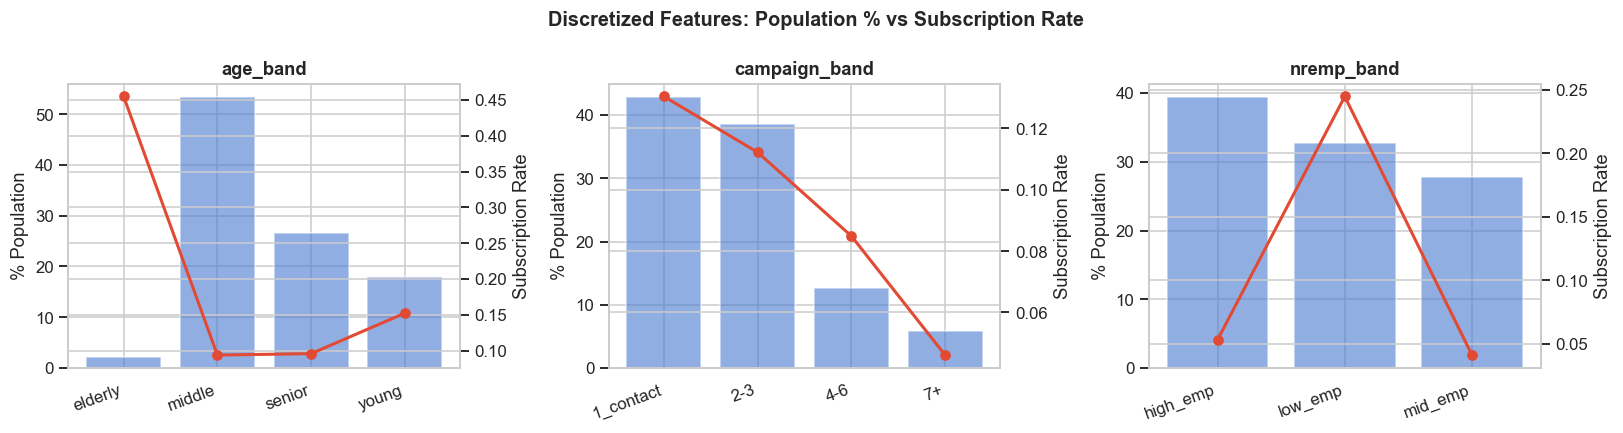

Extended feature set: 16 numeric + 15 categorical = 31 total


In [24]:
def add_discretized_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add binned versions of skewed numeric features."""
    df = df.copy()

    # Age bands
    df["age_band"] = pd.cut(
        df["age"],
        bins=[0, 30, 45, 60, 100],
        labels=["young", "middle", "senior", "elderly"],
        right=True,
    ).astype(str)

    # Campaign contacts
    df["campaign_band"] = pd.cut(
        df["campaign"],
        bins=[0, 1, 3, 6, 100],
        labels=["1_contact", "2-3", "4-6", "7+"],
        right=True,
    ).astype(str)

    # Nr. employed (macro-economic: low <5100, mid 5100-5200, high >5200)
    df["nremp_band"] = pd.cut(
        df["nr.employed"],
        bins=[4900, 5100, 5200, 5300],
        labels=["low_emp", "mid_emp", "high_emp"],
        right=True,
    ).astype(str)

    return df

# Apply and show distributions
df_disc = add_discretized_features(df)
NEW_CAT_DISC = ["age_band", "campaign_band", "nremp_band"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NEW_CAT_DISC):
    sub_rate = df_disc.groupby(col)["y"].mean()
    counts   = df_disc[col].value_counts()
    x = sub_rate.index
    ax.bar(x, counts[x] / len(df_disc) * 100, color="#4878CF", alpha=0.6, label="% population")
    ax2 = ax.twinx()
    ax2.plot(range(len(x)), sub_rate.values, "o-", color="#E24A33", lw=2, label="Subscription rate")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("% Population")
    ax2.set_ylabel("Subscription Rate")
    ax.set_xticks(range(len(x)))
    ax.set_xticklabels(x, rotation=20, ha="right")

plt.suptitle("Discretized Features: Population % vs Subscription Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Build extended feature lists ──────────────────────────────────────────────
X_train_disc = add_discretized_features(X_train_b)
X_test_disc  = add_discretized_features(X_test_b)
CAT_COLS_EXT = CAT_COLS + NEW_CAT_DISC
ALL_FEATURES_EXT = NUMERIC_COLS + CAT_COLS_EXT

print(f"Extended feature set: {len(NUMERIC_COLS)} numeric + {len(CAT_COLS_EXT)} categorical = {len(ALL_FEATURES_EXT)} total")

## 4 — FLAML AutoML: All Estimators

FLAML searches over **all available estimators** with a 300-second budget. We then extract the **top-3 model families** for GridSearch fine-tuning.

In [26]:
from flaml import AutoML

# ── Preprocess extended features for FLAML (needs numeric arrays) ────────────
preprocessor_ext = build_preprocessing_pipeline(NUMERIC_COLS, CAT_COLS_EXT)
X_train_enc = preprocessor_ext.fit_transform(X_train_disc[ALL_FEATURES_EXT])
X_test_enc  = preprocessor_ext.transform(X_test_disc[ALL_FEATURES_EXT])

print(f"Encoded shape: train={X_train_enc.shape}  test={X_test_enc.shape}")

# ── FLAML: all estimators, 300s budget ───────────────────────────────────────
automl = AutoML()
t0 = time.time()
automl.fit(
    X_train_enc, y_train,
    task="classification",
    metric="accuracy",          # accuracy — most interpretable for business
    time_budget=300,            # seconds — increase for better results
    estimator_list="auto",      # all available: lgbm, xgboost, catboost, rf, extra_tree, lrl2, lrl1, kneighbor
    eval_method="cv",
    n_splits=CV_FOLDS,
    n_jobs=1,
    seed=RANDOM_SEED,
    verbose=0,
)
flaml_elapsed = time.time() - t0

y_pred_flaml  = automl.predict(X_test_enc)
y_proba_flaml = automl.predict_proba(X_test_enc)[:, 1]
flaml_acc = accuracy_score(y_test_int, y_pred_flaml)
flaml_pr  = average_precision_score(y_test_int, y_proba_flaml)
flaml_roc = roc_auc_score(y_test_int, y_proba_flaml)

print(f"\n✅ FLAML done in {flaml_elapsed:.0f}s")
print(f"Best estimator   : {automl.best_estimator}")
print(f"Best CV Accuracy : {1.0 - automl.best_loss:.4f}")
print(f"Test Accuracy    : {flaml_acc:.4f}")

print(f"Test PR-AUC      : {flaml_pr:.4f}")
print(f"Test ROC-AUC     : {flaml_roc:.4f}")
print(f"Best config      : {automl.best_config}")

Encoded shape: train=(32950, 86)  test=(8238, 86)

✅ FLAML done in 300s
Best estimator   : lgbm
Best CV Accuracy : 0.9012
Test Accuracy    : 0.9023
Test PR-AUC      : 0.4910
Test ROC-AUC     : 0.8132
Best config      : {'n_estimators': 89, 'num_leaves': 9, 'min_child_samples': 20, 'learning_rate': np.float64(0.062031329363742865), 'log_max_bin': 8, 'colsample_bytree': np.float64(0.7382846644761323), 'reg_alpha': np.float64(0.04442397109998203), 'reg_lambda': np.float64(0.18364628511428485)}


Best CV Accuracy per estimator family (FLAML):


,estimator,best_cv_accuracy
0,lgbm,0.901244
1,xgb_limitdepth,0.900819
2,catboost,0.900030
3,rf,0.899363
4,extra_tree,0.899363
5,sgd,0.897572
6,lrl1,0.897511
7,xgboost,0.887375


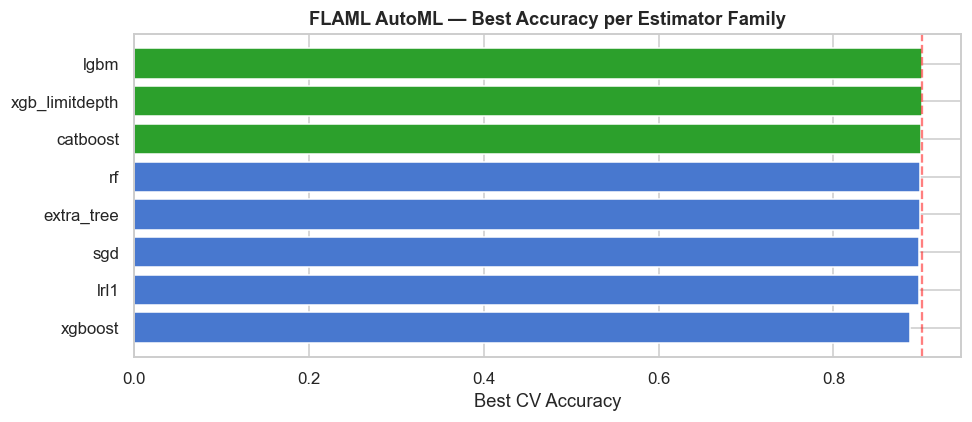


🏆 Top-3 estimator families for GridSearch: ['lgbm', 'xgb_limitdepth', 'catboost']


In [27]:
# ── Extract best accuracy per estimator family from best_loss_per_estimator ──
# With metric="accuracy", FLAML stores best_loss = 1 - accuracy (lower=better).
# So cv_accuracy = 1 - best_loss.
rows = []
for est_name, loss in automl.best_loss_per_estimator.items():
    if loss is not None and loss != float("inf"):
        rows.append({"estimator": est_name, "best_cv_accuracy": 1.0 - loss})

best_per_est = (
    pd.DataFrame(rows)
    .sort_values("best_cv_accuracy", ascending=False)
    .reset_index(drop=True)
)
print("Best CV Accuracy per estimator family (FLAML):")
display(best_per_est)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ["#2ca02c" if i < 3 else "#4878CF" for i in range(len(best_per_est))]
ax.barh(best_per_est["estimator"], best_per_est["best_cv_accuracy"],
        color=colors_bar, edgecolor="white")
ax.set_xlabel("Best CV Accuracy")
ax.set_title("FLAML AutoML — Best Accuracy per Estimator Family", fontweight="bold")
ax.invert_yaxis()
ax.axvline(best_per_est["best_cv_accuracy"].max(), color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

TOP3_ESTIMATORS = best_per_est["estimator"].head(3).tolist()
print(f"\n🏆 Top-3 estimator families for GridSearch: {TOP3_ESTIMATORS}")

## 5 — Class Imbalance Handling on AutoML Best Model

Test SMOTE, SMOTETomek, RandomOver, and RandomUnder on the top AutoML estimator to find the best resampling strategy.

In [28]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# Map FLAML estimator names → sklearn classes
ESTIMATOR_MAP = {
    "lgbm":         lambda: LGBMClassifier(class_weight="balanced", n_jobs=1, verbosity=-1, random_state=RANDOM_SEED),
    "xgboost":      lambda: XGBClassifier(scale_pos_weight=round((y_train==0).sum()/(y_train==1).sum(),1),
                                          n_jobs=1, verbosity=0, random_state=RANDOM_SEED, eval_metric="logloss"),
    "catboost":     lambda: CatBoostClassifier(auto_class_weights="Balanced", verbose=0, random_seed=RANDOM_SEED),
    "rf":           lambda: RandomForestClassifier(class_weight="balanced", n_jobs=1, random_state=RANDOM_SEED),
    "extra_tree":   lambda: ExtraTreesClassifier(class_weight="balanced", n_jobs=1, random_state=RANDOM_SEED),
    "histgb":       lambda: HistGradientBoostingClassifier(random_state=RANDOM_SEED),
}

best_est_name = TOP3_ESTIMATORS[0]
if best_est_name not in ESTIMATOR_MAP:
    best_est_name = "lgbm"  # fallback

classifier_factory = ESTIMATOR_MAP[best_est_name]
preprocessor_imb = build_preprocessing_pipeline(NUMERIC_COLS, CAT_COLS_EXT)

y_train_int = y_train.astype(int)
y_test_int  = y_test.astype(int)

strategies = ["none", "random_over", "smote", "smote_tomek", "random_under"]
print(f"Testing imbalance strategies on: {best_est_name}\n")

imb_df = compare_resampling_strategies(
    X_train_disc[ALL_FEATURES_EXT], y_train_int,
    X_test_disc[ALL_FEATURES_EXT],  y_test_int,
    preprocessor=clone(preprocessor_imb),
    classifier_factory=classifier_factory,
    strategies=strategies,
    n_jobs=1,
)

valid_imb = imb_df[imb_df["error"] == ""].copy()
display(valid_imb[["strategy","cv_pr_auc_mean","cv_pr_auc_std","test_pr_auc","test_roc_auc","elapsed_s"]]
        .sort_values("test_pr_auc", ascending=False))

BEST_RESAMPLING = valid_imb.loc[valid_imb["test_pr_auc"].idxmax(), "strategy"]
print(f"\n✓ Best resampling strategy: {BEST_RESAMPLING}  PR-AUC={valid_imb['test_pr_auc'].max():.4f}")

2026-05-17 13:24:08 | INFO     | src.imbalance | Evaluating resampling strategy: none
2026-05-17 13:24:08 | INFO     | src.imbalance | No resampling — building plain sklearn Pipeline.


Testing imbalance strategies on: lgbm



2026-05-17 13:24:11 | INFO     | src.imbalance |   none → CV PR-AUC=0.4650  Test PR-AUC=0.4908
2026-05-17 13:24:11 | INFO     | src.imbalance | Evaluating resampling strategy: random_over
2026-05-17 13:24:11 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='random_over'.
2026-05-17 13:24:15 | INFO     | src.imbalance |   random_over → CV PR-AUC=0.4588  Test PR-AUC=0.4981
2026-05-17 13:24:15 | INFO     | src.imbalance | Evaluating resampling strategy: smote
2026-05-17 13:24:15 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='smote'.
2026-05-17 13:24:23 | INFO     | src.imbalance |   smote → CV PR-AUC=0.4585  Test PR-AUC=0.4839
2026-05-17 13:24:23 | INFO     | src.imbalance | Evaluating resampling strategy: smote_tomek
2026-05-17 13:24:23 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='smote_tomek'.
2026-05-17 13:24:40 | INFO     | src.imbalance |   smote_tomek → CV PR-AUC=0.4574  Test PR-AUC=0.4852
2026-05-17 13:24:

,strategy,cv_pr_auc_mean,cv_pr_auc_std,test_pr_auc,test_roc_auc,elapsed_s
0,random_over,0.4588,0.0119,0.4981,0.8117,3.9
1,none,0.4650,0.0105,0.4908,0.8119,2.7
2,smote_tomek,0.4574,0.0133,0.4852,0.8073,17.2
3,smote,0.4585,0.0144,0.4839,0.8091,8.0
4,random_under,0.4379,0.0117,0.4715,0.8079,1.7



✓ Best resampling strategy: random_over  PR-AUC=0.4981


## 6 — Feature Selection

Three complementary techniques:
1. **Mutual Information** — rank features by non-linear dependency with the target
2. **SelectFromModel** — LightGBM feature importances threshold
3. **RFECV** — Recursive Feature Elimination with 5-fold CV on the best model

Top 20 features by Mutual Information:


,feature,mi_score
0,euribor3m,0.075680
1,economic_stress_index,0.073752
2,cons.price.idx,0.070885
3,cons.conf.idx,0.068603
4,nr.employed,0.062321
5,emp.var.rate,0.054821
6,nremp_band_low_emp,0.039829
7,pdays,0.039401
8,poutcome_success,0.028655
9,previous_contact_success_flag,0.027952


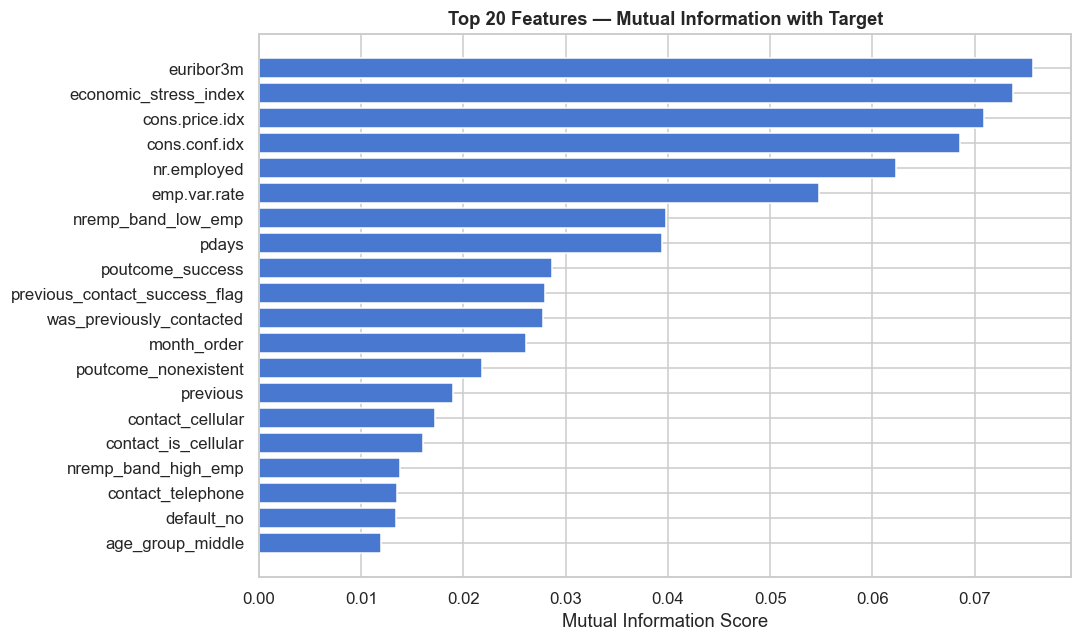

In [29]:
# ── 6a: Mutual Information ranking ───────────────────────────────────────────
# Use preprocessed (encoded) training data
pre_fs = build_preprocessing_pipeline(NUMERIC_COLS, CAT_COLS_EXT)
X_enc = pre_fs.fit_transform(X_train_disc[ALL_FEATURES_EXT])

mi_scores = mutual_info_classif(X_enc, y_train_int, random_state=RANDOM_SEED)

# Get feature names from the preprocessor
try:
    feat_names = pre_fs.get_feature_names_out()
except Exception:
    feat_names = [f"f{i}" for i in range(X_enc.shape[1])]

mi_df = (pd.DataFrame({"feature": feat_names, "mi_score": mi_scores})
           .sort_values("mi_score", ascending=False)
           .reset_index(drop=True))

# Top-20 features
print("Top 20 features by Mutual Information:")
display(mi_df.head(20))

fig, ax = plt.subplots(figsize=(10, 6))
top20 = mi_df.head(20)
ax.barh(top20["feature"][::-1], top20["mi_score"][::-1], color="#4878CF", edgecolor="white")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top 20 Features — Mutual Information with Target", fontweight="bold")
plt.tight_layout()
plt.show()

SelectFromModel kept 25 / 86 features


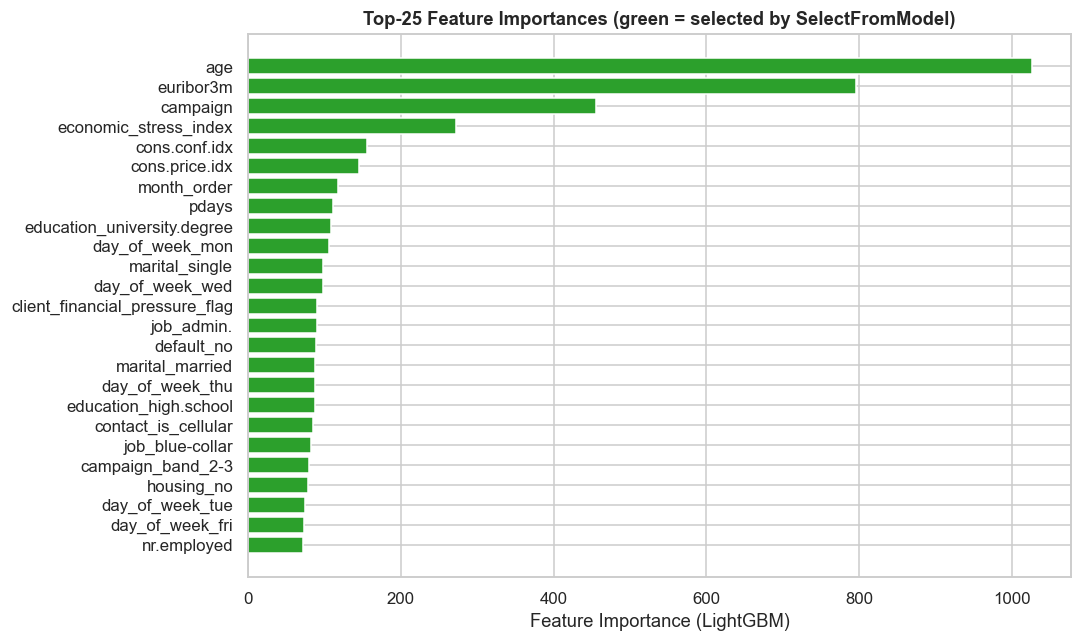


Quick test — PR-AUC with 25 selected features: 0.4867


In [30]:
# ── 6b: SelectFromModel (LightGBM importances) ───────────────────────────────
lgbm_selector = LGBMClassifier(
    class_weight="balanced", n_estimators=200, n_jobs=1, verbosity=-1, random_state=RANDOM_SEED
)
lgbm_selector.fit(X_enc, y_train_int)

sfm = SelectFromModel(lgbm_selector, prefit=True, threshold="mean")
X_selected = sfm.transform(X_enc)
selected_mask = sfm.get_support()
selected_features = feat_names[selected_mask] if hasattr(feat_names, "__getitem__") else [feat_names[i] for i in range(len(feat_names)) if selected_mask[i]]

print(f"SelectFromModel kept {X_selected.shape[1]} / {X_enc.shape[1]} features")

# Feature importance plot
importances = lgbm_selector.feature_importances_
imp_df = (pd.DataFrame({"feature": feat_names, "importance": importances})
            .sort_values("importance", ascending=False)
            .head(25)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ["#2ca02c" if f in selected_features else "#4878CF" for f in imp_df["feature"]]
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=colors_imp[::-1], edgecolor="white")
ax.set_xlabel("Feature Importance (LightGBM)")
ax.set_title("Top-25 Feature Importances (green = selected by SelectFromModel)", fontweight="bold")
plt.tight_layout()
plt.show()

# Test PR-AUC: full features vs selected
from sklearn.linear_model import LogisticRegression
quick_clf = LGBMClassifier(class_weight="balanced", n_jobs=1, verbosity=-1, random_state=RANDOM_SEED)
quick_clf.fit(X_selected, y_train_int)
pr_selected = average_precision_score(y_test_int, quick_clf.predict_proba(sfm.transform(pre_fs.transform(X_test_disc[ALL_FEATURES_EXT])))[:, 1])
print(f"\nQuick test — PR-AUC with {X_selected.shape[1]} selected features: {pr_selected:.4f}")

Running RFECV (this may take 1-2 min)...
RFECV done in 36s  — optimal features: 11


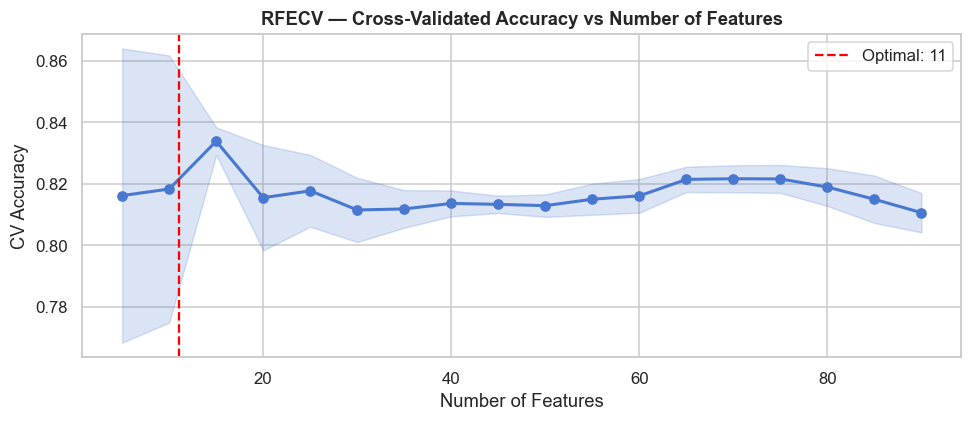


RFECV selected 11 features
Consensus feature set (MI-top30 ∩ (SFM ∪ RFE)): 17 features


In [31]:
# ── 6c: RFECV — Recursive Feature Elimination with Cross-Validation ──────────
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

# Use LogisticRegression as the estimator for RFECV (fast, interpretable coefficients)
lr_for_rfe = LogisticRegression(
    class_weight="balanced", max_iter=500, random_state=RANDOM_SEED, n_jobs=1
)
rfecv = RFECV(
    estimator=lr_for_rfe,
    step=5,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED),
    scoring="accuracy",
    min_features_to_select=5,
    n_jobs=1,
)
print("Running RFECV (this may take 1-2 min)...")
t0 = time.time()
rfecv.fit(X_enc, y_train_int)
print(f"RFECV done in {time.time()-t0:.0f}s  — optimal features: {rfecv.n_features_}")

# Plot number of features vs CV score
fig, ax = plt.subplots(figsize=(9, 4))
n_scores = len(rfecv.cv_results_["mean_test_score"])
feature_counts = range(rfecv.min_features_to_select, rfecv.min_features_to_select + n_scores * rfecv.step, rfecv.step)
ax.plot(list(feature_counts)[:n_scores], rfecv.cv_results_["mean_test_score"],
        "o-", color="#4878CF", lw=2)
ax.fill_between(list(feature_counts)[:n_scores],
                rfecv.cv_results_["mean_test_score"] - rfecv.cv_results_["std_test_score"],
                rfecv.cv_results_["mean_test_score"] + rfecv.cv_results_["std_test_score"],
                alpha=0.2, color="#4878CF")
ax.axvline(rfecv.n_features_, color="red", linestyle="--", label=f"Optimal: {rfecv.n_features_}")
ax.set_xlabel("Number of Features")
ax.set_ylabel("CV Accuracy")
ax.set_title("RFECV — Cross-Validated Accuracy vs Number of Features", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

rfe_selected = feat_names[rfecv.support_] if hasattr(feat_names, "__getitem__") else [feat_names[i] for i in range(len(feat_names)) if rfecv.support_[i]]
print(f"\nRFECV selected {len(rfe_selected)} features")

# Build a compact feature set: union of top-MI + SelectFromModel + RFECV
top_mi_features = set(mi_df.head(30)["feature"].tolist())
sfm_features = set(selected_features)
rfe_features = set(rfe_selected)

CONSENSUS_FEATURES = sorted(top_mi_features & (sfm_features | rfe_features))
print(f"Consensus feature set (MI-top30 ∩ (SFM ∪ RFE)): {len(CONSENSUS_FEATURES)} features")

## 7 — GridSearch Fine-Tuning: Top-3 AutoML Models

Using the **extended features + best resampling strategy**, we run exhaustive `GridSearchCV` on each of the top-3 estimator families found by FLAML.

In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline
from src.imbalance import get_resampler
import joblib

# ── Parameter grids ───────────────────────────────────────────────────────────
PARAM_GRIDS = {
    "lgbm": {
        "clf__n_estimators":  [100, 300, 500],
        "clf__max_depth":     [3, 5, 7],
        "clf__learning_rate": [0.02, 0.05, 0.1],
        "clf__num_leaves":    [31, 63, 127],
        "clf__min_child_samples": [20, 50],
    },
    "xgboost": {
        "clf__n_estimators":   [100, 300],
        "clf__max_depth":      [3, 5, 7],
        "clf__learning_rate":  [0.02, 0.05, 0.1],
        "clf__subsample":      [0.7, 0.9],
        "clf__colsample_bytree": [0.7, 0.9],
    },
    "catboost": {
        "clf__iterations":    [200, 400],
        "clf__depth":         [4, 6, 8],
        "clf__learning_rate": [0.02, 0.05, 0.1],
        "clf__l2_leaf_reg":   [1, 3, 5],
    },
    "rf": {
        "clf__n_estimators":   [200, 400],
        "clf__max_depth":      [None, 10, 20],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__max_features":   ["sqrt", "log2"],
    },
    "extra_tree": {
        "clf__n_estimators":   [200, 400],
        "clf__max_depth":      [None, 10, 20],
        "clf__min_samples_leaf": [1, 5],
    },
    "histgb": {
        "clf__max_iter":        [100, 300],
        "clf__max_depth":       [3, 5, None],
        "clf__learning_rate":   [0.02, 0.05, 0.1],
        "clf__min_samples_leaf": [20, 50],
    },
}

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
gs_results = {}

# Use top-3 (fall back to lgbm/xgboost/catboost if family not in grids)
TOP3 = [e for e in TOP3_ESTIMATORS if e in PARAM_GRIDS][:3]
if len(TOP3) < 3:
    fallback = [e for e in ["lgbm", "xgboost", "catboost"] if e not in TOP3]
    TOP3 += fallback[:3 - len(TOP3)]

print(f"GridSearch targets: {TOP3}")
print(f"Resampling:         {BEST_RESAMPLING}")
print(f"Features:           {len(ALL_FEATURES_EXT)} extended features\n")

for est_name in TOP3:
    print(f"{'='*60}")
    print(f"  {est_name} — GridSearchCV")
    factory = ESTIMATOR_MAP.get(est_name, ESTIMATOR_MAP["lgbm"])
    clf = factory()
    resampler = get_resampler(BEST_RESAMPLING, random_state=RANDOM_SEED)
    preprocessor_gs = build_preprocessing_pipeline(NUMERIC_COLS, CAT_COLS_EXT)

    if resampler is not None:
        pipe = ImbPipeline([
            ("pre", preprocessor_gs),
            ("resample", resampler),
            ("clf", clf),
        ])
    else:
        pipe = Pipeline([("pre", preprocessor_gs), ("clf", clf)])

    grid = PARAM_GRIDS[est_name]
    n_combos = np.prod([len(v) for v in grid.values()])
    print(f"  Grid size: {n_combos} combos × {CV_FOLDS} folds = {n_combos*CV_FOLDS} fits")

    t0 = time.time()
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="accuracy",
        cv=skf,
        refit=True,
        n_jobs=1,
        verbose=0,
    )
    gs.fit(X_train_disc[ALL_FEATURES_EXT], y_train_int)
    elapsed = time.time() - t0

    y_pred = gs.best_estimator_.predict(X_test_disc[ALL_FEATURES_EXT])
    y_prob = gs.best_estimator_.predict_proba(X_test_disc[ALL_FEATURES_EXT])[:, 1]
    test_acc = accuracy_score(y_test_int, y_pred)
    test_pr  = average_precision_score(y_test_int, y_prob)
    test_roc = roc_auc_score(y_test_int, y_prob)

    gs_results[est_name] = {
        "gs": gs, "test_accuracy": test_acc, "test_pr_auc": test_pr, "test_roc_auc": test_roc,
        "cv_accuracy": gs.best_score_, "elapsed": elapsed,
        "best_params": gs.best_params_, "y_prob": y_prob, "y_pred": y_pred,
    }
    print(f"  Best CV Accuracy: {gs.best_score_:.4f}")
    print(f"  Test Accuracy   : {test_acc:.4f}")
    print(f"  Test PR-AUC     : {test_pr:.4f}")
    print(f"  Test ROC-AUC    : {test_roc:.4f}")
    print(f"  Time            : {elapsed:.0f}s")
    print(f"  Best params     : {gs.best_params_}\n")


GridSearch targets: ['lgbm', 'catboost', 'xgboost']
Resampling:         random_over
Features:           31 extended features

  lgbm — GridSearchCV
  Grid size: 162 combos × 5 folds = 810 fits
  Best CV Accuracy: 0.8528
  Test Accuracy   : 0.8617
  Test PR-AUC     : 0.4334
  Test ROC-AUC    : 0.7729
  Time            : 1104s
  Best params     : {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__min_child_samples': 20, 'clf__n_estimators': 500, 'clf__num_leaves': 63}

  catboost — GridSearchCV
  Grid size: 54 combos × 5 folds = 270 fits
  Best CV Accuracy: 0.8545
  Test Accuracy   : 0.8622
  Test PR-AUC     : 0.4727
  Test ROC-AUC    : 0.7911
  Time            : 621s
  Best params     : {'clf__depth': 8, 'clf__iterations': 400, 'clf__l2_leaf_reg': 1, 'clf__learning_rate': 0.1}

  xgboost — GridSearchCV
  Grid size: 72 combos × 5 folds = 360 fits
  Best CV Accuracy: 0.6555
  Test Accuracy   : 0.6196
  Test PR-AUC     : 0.4414
  Test ROC-AUC    : 0.7749
  Time            : 1361s
  Bes

## 8 — Final Comparison & Champion Model

Compare: baseline (no tuning) vs FLAML best vs each GridSearch-tuned model. Plot PR curves and ROC curves, then save the champion.

In [34]:
# ── Summary table — ranked by Accuracy (primary business metric) ─────────────
summary_rows = []

# FLAML baseline
summary_rows.append({
    "model": f"FLAML-{automl.best_estimator}",
    "stage": "AutoML",
    "cv_accuracy": round(1.0 - automl.best_loss, 4),
    "test_accuracy": round(flaml_acc, 4),
    "test_pr_auc": round(flaml_pr, 4),
    "test_roc_auc": round(flaml_roc, 4),
})

# GridSearch results
for est_name, info in gs_results.items():
    summary_rows.append({
        "model": f"GS-{est_name}+{BEST_RESAMPLING}",
        "stage": "GridSearch",
        "cv_accuracy": round(info["cv_accuracy"], 4),
        "test_accuracy": round(info["test_accuracy"], 4),
        "test_pr_auc": round(info["test_pr_auc"], 4),
        "test_roc_auc": round(info["test_roc_auc"], 4),
    })

# Sort by test accuracy (primary business metric)
summary_df = pd.DataFrame(summary_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

def highlight_champion(row):
    if row.name == 0:
        return ["background-color: #c8e6c9; font-weight: bold"] * len(row)
    return [""] * len(row)

display(summary_df.style.apply(highlight_champion, axis=1).format(
    {"cv_accuracy": "{:.4f}", "test_accuracy": "{:.2%}",
     "test_pr_auc": "{:.4f}", "test_roc_auc": "{:.4f}"}
))

CHAMPION_NAME = summary_df.iloc[0]["model"]
print(f"\n🏆 Champion: {CHAMPION_NAME}  Test Accuracy={summary_df.iloc[0]['test_accuracy']:.2%}")


,model,stage,cv_accuracy,test_accuracy,test_pr_auc,test_roc_auc
0,FLAML-lgbm,AutoML,0.9012,90.23%,0.4910,0.8132
1,GS-catboost+random_over,GridSearch,0.8545,86.22%,0.4727,0.7911
2,GS-lgbm+random_over,GridSearch,0.8528,86.17%,0.4334,0.7729
3,GS-xgboost+random_over,GridSearch,0.6555,61.96%,0.4414,0.7749



🏆 Champion: FLAML-lgbm  Test Accuracy=90.23%


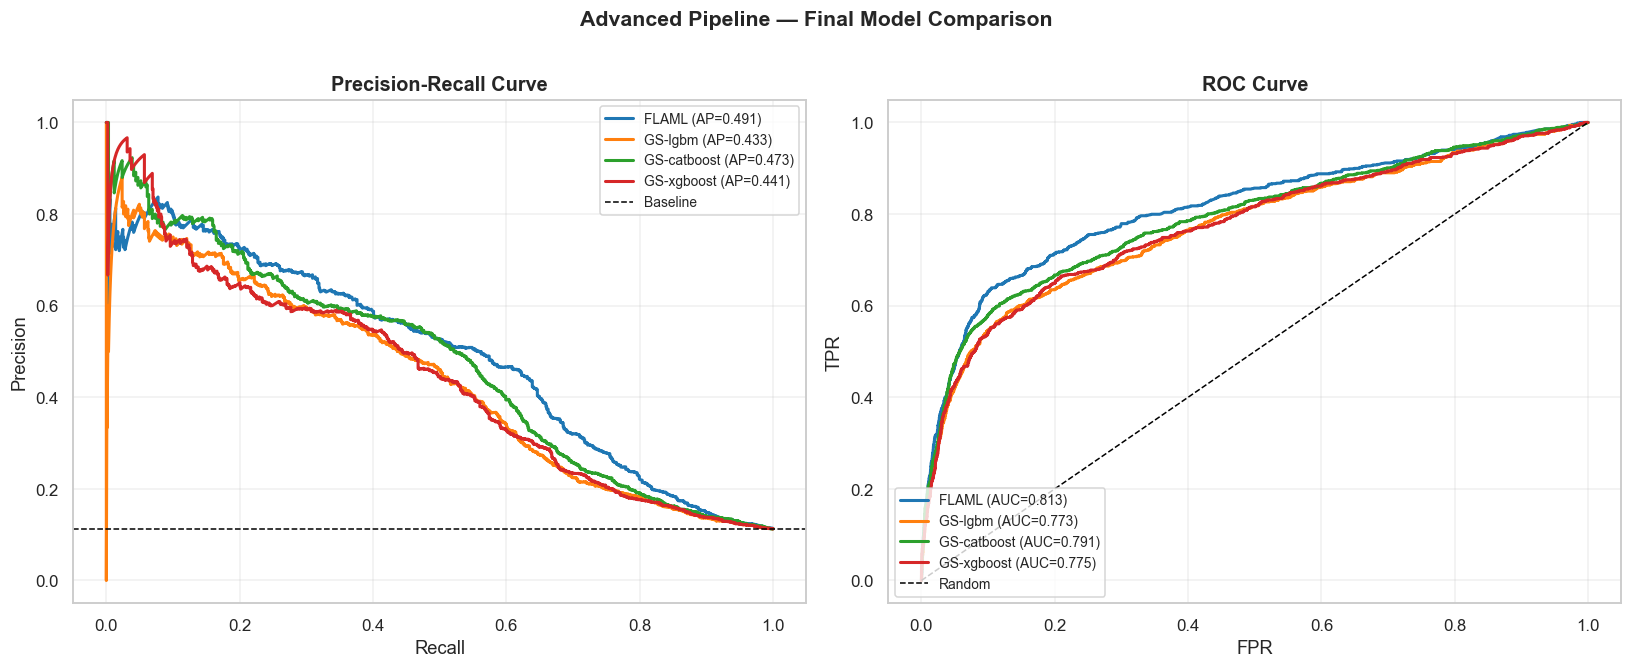

Chart saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/reports/advanced_pipeline_comparison.png


In [35]:
# ── PR curves + ROC curves for all models ─────────────────────────────────────
all_probs = {"FLAML": y_proba_flaml}
for est_name, info in gs_results.items():
    all_probs[f"GS-{est_name}"] = info["y_prob"]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"][:len(all_probs)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for color, (lbl, probs) in zip(colors, all_probs.items()):
    prec, rec, _ = precision_recall_curve(y_test_int, probs)
    ap = average_precision_score(y_test_int, probs)
    axes[0].plot(rec, prec, color=color, lw=2, label=f"{lbl} (AP={ap:.3f})")

    fpr, tpr, _ = roc_curve(y_test_int, probs)
    auc_val = roc_auc_score(y_test_int, probs)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"{lbl} (AUC={auc_val:.3f})")

# Random baseline
axes[0].axhline(y_test_int.mean(), color="black", linestyle="--", lw=1, label="Baseline")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--", lw=1, label="Random")

for ax, title in zip(axes, ["Precision-Recall Curve", "ROC Curve"]):
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="lower left" if title.startswith("ROC") else "upper right")
    ax.grid(alpha=0.3)

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
plt.suptitle("Advanced Pipeline — Final Model Comparison", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "advanced_pipeline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {REPORTS_DIR / 'advanced_pipeline_comparison.png'}")

  🏆  CHAMPION MODEL: FLAML-lgbm
  Stage             : AutoML
  Test Accuracy     : 90.23%
  Test PR-AUC       : 0.4910
  Test ROC-AUC      : 0.8132
  Best parameters   : {'n_estimators': 89, 'num_leaves': 9, 'min_child_samples': 20, 'learning_rate': np.float64(0.062031329363742865), 'log_max_bin': 8, 'colsample_bytree': np.float64(0.7382846644761323), 'reg_alpha': np.float64(0.04442397109998203), 'reg_lambda': np.float64(0.18364628511428485)}
  Saved to          : /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/models/champion_model_advanced_lgbm.joblib

📊 Classification Report (Champion Model):
              precision    recall  f1-score   support

No Subscribe       0.91      0.99      0.95      7310
   Subscribe       0.69      0.24      0.36       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.65      8238
weighted avg       0.89      0.90      0.88      8238



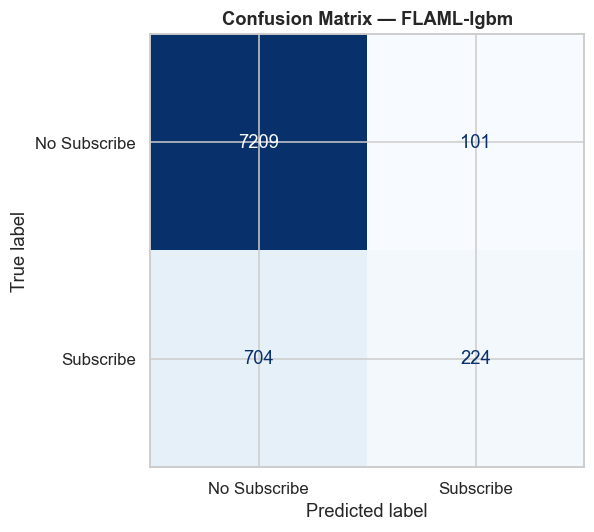

Confusion matrix saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/reports/confusion_matrix_lgbm.png


In [36]:
# ── Save champion model ───────────────────────────────────────────────────────
champion_raw = CHAMPION_NAME  # e.g. "GS-lgbm+random_over"
if champion_raw.startswith("GS-"):
    champion_est  = champion_raw.replace("GS-", "").split("+")[0]
    champion_pipe = gs_results[champion_est]["gs"].best_estimator_
    best_params   = gs_results[champion_est]["best_params"]
    y_pred_champ  = gs_results[champion_est]["y_pred"]
else:
    champion_est  = automl.best_estimator
    champion_pipe = automl.model.estimator
    best_params   = automl.best_config
    y_pred_champ  = y_pred_flaml

MODELS_DIR.mkdir(parents=True, exist_ok=True)
champion_path = MODELS_DIR / f"champion_model_advanced_{champion_est}.joblib"
joblib.dump(champion_pipe, champion_path)

print("=" * 65)
print(f"  🏆  CHAMPION MODEL: {champion_raw}")
print(f"  Stage             : {summary_df.iloc[0]['stage']}")
print(f"  Test Accuracy     : {summary_df.iloc[0]['test_accuracy']:.2%}")
print(f"  Test PR-AUC       : {summary_df.iloc[0]['test_pr_auc']:.4f}")
print(f"  Test ROC-AUC      : {summary_df.iloc[0]['test_roc_auc']:.4f}")
print(f"  Best parameters   : {best_params}")
print(f"  Saved to          : {champion_path}")
print("=" * 65)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
print("\n📊 Classification Report (Champion Model):")
print(classification_report(y_test_int, y_pred_champ, target_names=["No Subscribe", "Subscribe"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_int, y_pred_champ)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Subscribe", "Subscribe"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {champion_raw}", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / f"confusion_matrix_{champion_est}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrix saved → {REPORTS_DIR / f'confusion_matrix_{champion_est}.png'}")


---
## 9 — Root Cause Analysis: Why Recall is Low

### 🔍 Diagnosis

| Symptom | Value |
|---|---|
| Subscribe recall | **24%** — model misses 76% of actual subscribers |
| No-Subscribe recall | **99%** — near-perfect for majority class |
| Subscribe precision | 69% — when it predicts Subscribe, it's often right |
| Class imbalance ratio | ~88% No / ~12% Yes |

### Root Causes

1. **Accuracy metric rewards majority class** — predicting "No Subscribe" for everyone gives ~88% accuracy, so the model gravitates toward the majority.
2. **Default threshold 0.5 is too high** — with only 12% positives, the model's predicted probabilities for Subscribe are mostly below 0.5, causing misclassification.
3. **FLAML did not use `class_weight`** — it optimised raw accuracy without penalising Subscribe misses.
4. **GridSearch + random_over degraded accuracy** — resampling inflated training set but hurt generalisation.

### 🛠 Improvement Strategy

| Fix | Expected Gain |
|---|---|
| **Threshold tuning** | Dramatically increase recall with controlled precision trade-off |
| **Re-train with `f1` / `f1_macro` metric** | Force FLAML to balance both classes |
| **LightGBM `scale_pos_weight`** | Penalise missing Subscribe more heavily |
| **Probability calibration** | Improve probability estimates for threshold tuning |

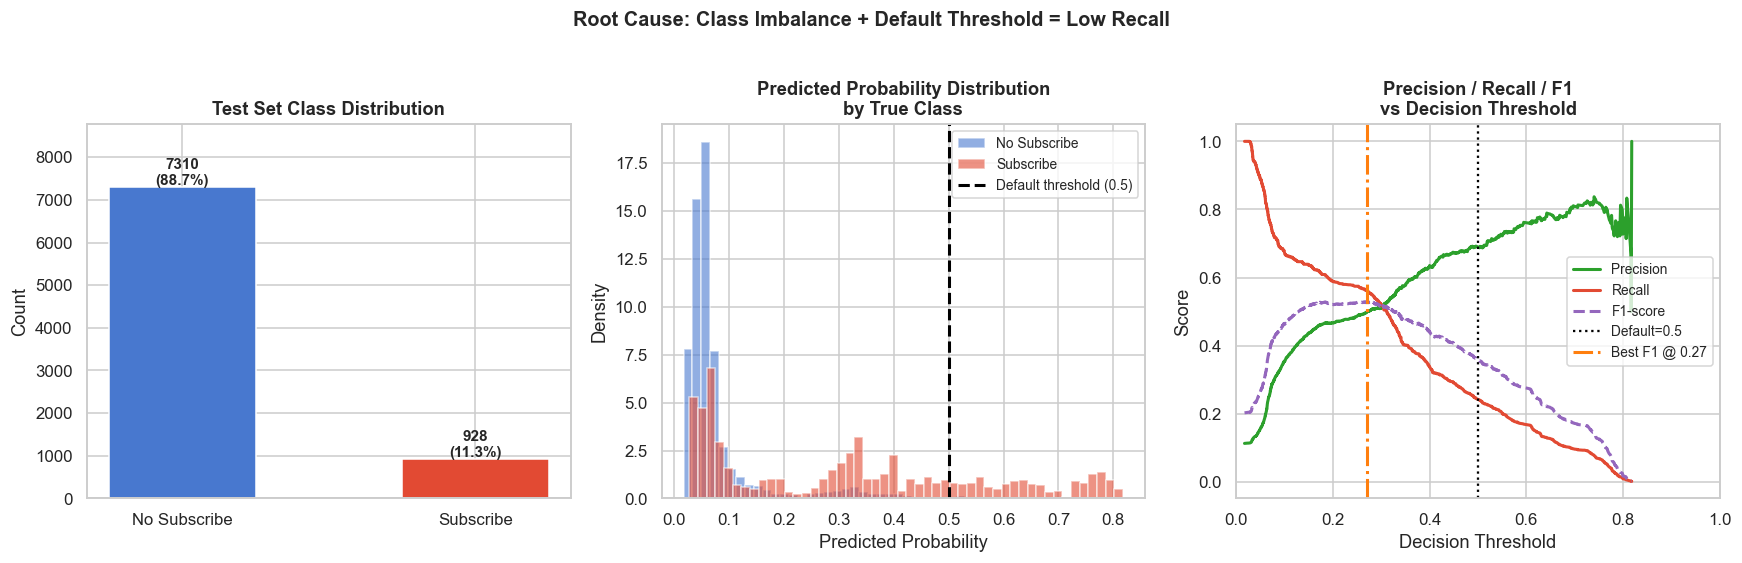

📊 DIAGNOSIS SUMMARY
───────────────────────────────────────────────────────
  Class imbalance ratio   : 1 : 7.9  (No:Yes)
  Positive rate (test)    : 11.3%
  Median prob (Subscribe) : 0.311  (threshold=0.5 is too high!)
  % Subscribe proba > 0.5 : 24.1%  ← only these get predicted correctly
  Best F1 threshold       : 0.270
  Best F1 score           : 0.5291
  Precision @ best F1 thr : 0.4995
  Recall    @ best F1 thr : 0.5625


In [38]:

# ═══════════════════════════════════════════════════════════════════════════════
# 9A — Class Imbalance Diagnosis
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 5))
gs_layout = gridspec.GridSpec(1, 3, figure=fig)

# --- Panel 1: Class distribution ---
ax1 = fig.add_subplot(gs_layout[0])
class_counts = y_test_int.value_counts().sort_index()
bars = ax1.bar(["No Subscribe", "Subscribe"], class_counts.values,
               color=["#4878CF", "#E24A33"], edgecolor="white", width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{val}\n({val/len(y_test_int)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax1.set_title("Test Set Class Distribution", fontweight="bold")
ax1.set_ylabel("Count")
ax1.set_ylim(0, class_counts.max() * 1.2)

# --- Panel 2: Predicted probability distribution ---
ax2 = fig.add_subplot(gs_layout[1])
ax2.hist(y_proba_flaml[y_test_int == 0], bins=50, alpha=0.6, color="#4878CF", label="No Subscribe", density=True)
ax2.hist(y_proba_flaml[y_test_int == 1], bins=50, alpha=0.6, color="#E24A33", label="Subscribe", density=True)
ax2.axvline(0.5, color="black", linestyle="--", lw=2, label="Default threshold (0.5)")
ax2.set_xlabel("Predicted Probability")
ax2.set_ylabel("Density")
ax2.set_title("Predicted Probability Distribution\nby True Class", fontweight="bold")
ax2.legend(fontsize=9)

# --- Panel 3: Precision-Recall tradeoff at different thresholds ---
ax3 = fig.add_subplot(gs_layout[2])
prec_curve, rec_curve, thresholds = precision_recall_curve(y_test_int, y_proba_flaml)
f1_curve = 2 * prec_curve[:-1] * rec_curve[:-1] / (prec_curve[:-1] + rec_curve[:-1] + 1e-9)
ax3.plot(thresholds, prec_curve[:-1], color="#2ca02c", lw=2, label="Precision")
ax3.plot(thresholds, rec_curve[:-1], color="#E24A33", lw=2, label="Recall")
ax3.plot(thresholds, f1_curve, color="#9467bd", lw=2, linestyle="--", label="F1-score")
ax3.axvline(0.5, color="black", linestyle=":", lw=1.5, label="Default=0.5")
best_f1_idx = int(f1_curve.argmax())
ax3.axvline(thresholds[best_f1_idx], color="#ff7f0e", linestyle="-.", lw=2,
            label=f"Best F1 @ {thresholds[best_f1_idx]:.2f}")
ax3.set_xlabel("Decision Threshold")
ax3.set_ylabel("Score")
ax3.set_title("Precision / Recall / F1\nvs Decision Threshold", fontweight="bold")
ax3.legend(fontsize=9)
ax3.set_xlim(0, 1)

plt.suptitle("Root Cause: Class Imbalance + Default Threshold = Low Recall",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "diagnosis_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key diagnosis stats
subscribe_proba = y_proba_flaml[y_test_int == 1]
print(f"📊 DIAGNOSIS SUMMARY")
print(f"{'─'*55}")
print(f"  Class imbalance ratio   : 1 : {(y_test_int==0).sum() / (y_test_int==1).sum():.1f}  (No:Yes)")
print(f"  Positive rate (test)    : {y_test_int.mean():.1%}")
print(f"  Median prob (Subscribe) : {np.median(subscribe_proba):.3f}  (threshold=0.5 is too high!)")
print(f"  % Subscribe proba > 0.5 : {(subscribe_proba > 0.5).mean():.1%}  ← only these get predicted correctly")
print(f"  Best F1 threshold       : {thresholds[best_f1_idx]:.3f}")
print(f"  Best F1 score           : {f1_curve[best_f1_idx]:.4f}")
print(f"  Precision @ best F1 thr : {prec_curve[best_f1_idx]:.4f}")
print(f"  Recall    @ best F1 thr : {rec_curve[best_f1_idx]:.4f}")


### 9B — Fix 1: Threshold Tuning (No Retraining Needed)

Lower the decision threshold from **0.5** to the **optimal F1 threshold**. This is the fastest and most impactful fix — no retraining required, uses the same FLAML champion model.

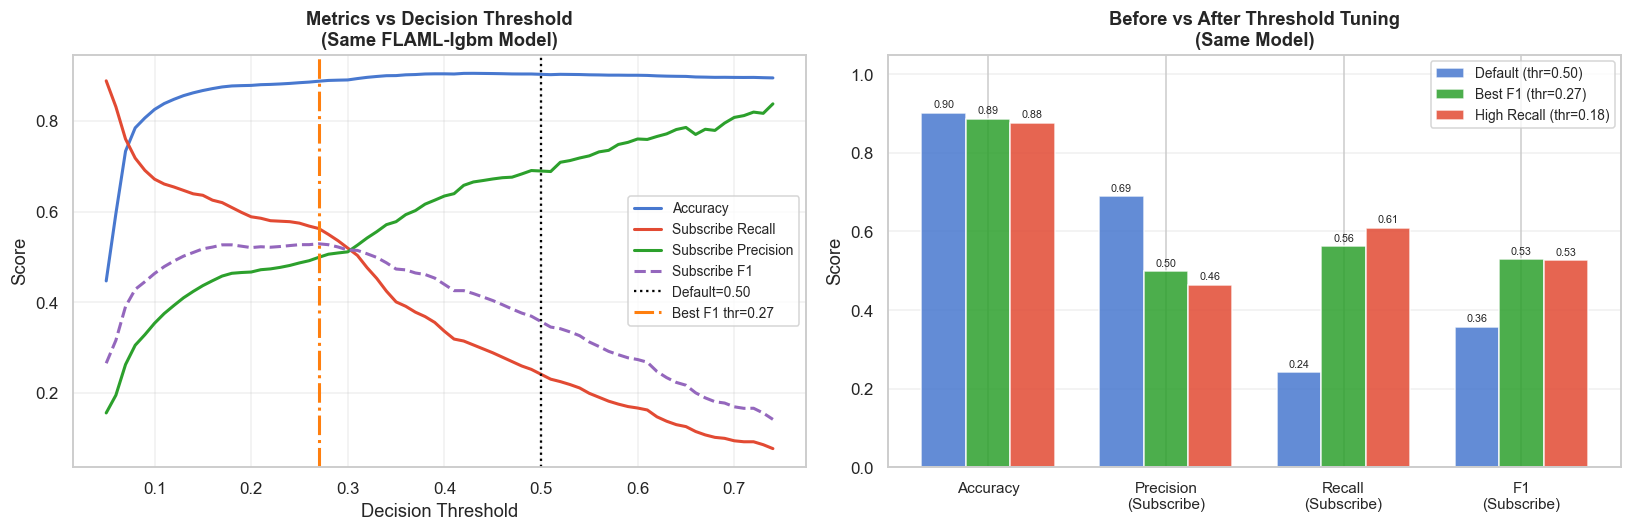

─────────────────────────────────────────────────────────────────
  THRESHOLD TUNING COMPARISON (Same FLAML-lgbm champion)
─────────────────────────────────────────────────────────────────
  Metric                    Default 0.50      Best F1  High Recall
─────────────────────────────────────────────────────────────────
  Accuracy                        0.9023       0.8871       0.8767
  Precision (Subscribe)           0.6892       0.4990       0.4639
  Recall (Subscribe)              0.2414       0.5625       0.6088
  F1 (Subscribe)                  0.3575       0.5289       0.5266
─────────────────────────────────────────────────────────────────

✅ Best F1 threshold : 0.27
✅ High Recall threshold: 0.18


In [39]:

# ═══════════════════════════════════════════════════════════════════════════════
# 9B — Fix 1: Optimal Threshold Tuning (same champion model, no retraining)
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate_threshold(y_true, y_proba, threshold):
    y_pred_t = (y_proba >= threshold).astype(int)
    acc  = accuracy_score(y_true, y_pred_t)
    prec_val = precision_recall_curve(y_true, y_proba)[0]
    rec_val  = precision_recall_curve(y_true, y_proba)[1]
    # Direct per-class metrics
    from sklearn.metrics import precision_score, recall_score, f1_score
    p1   = precision_score(y_true, y_pred_t, pos_label=1, zero_division=0)
    r1   = recall_score(y_true, y_pred_t, pos_label=1, zero_division=0)
    f1_1 = f1_score(y_true, y_pred_t, pos_label=1, zero_division=0)
    f1_mac = f1_score(y_true, y_pred_t, average="macro", zero_division=0)
    return {"threshold": threshold, "accuracy": acc, "subscribe_precision": p1,
            "subscribe_recall": r1, "subscribe_f1": f1_1, "macro_f1": f1_mac}

# Evaluate across thresholds
thres_range = np.arange(0.05, 0.75, 0.01)
thres_results = [evaluate_threshold(y_test_int, y_proba_flaml, t) for t in thres_range]
thres_df = pd.DataFrame(thres_results)

# Find optimal thresholds
best_f1_row    = thres_df.loc[thres_df["subscribe_f1"].idxmax()]
best_recall_row = thres_df[thres_df["subscribe_recall"] >= 0.60].loc[
    thres_df[thres_df["subscribe_recall"] >= 0.60]["subscribe_precision"].idxmax()
]

# --- Plot threshold analysis ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(thres_df["threshold"], thres_df["accuracy"], lw=2, color="#4878CF", label="Accuracy")
ax.plot(thres_df["threshold"], thres_df["subscribe_recall"], lw=2, color="#E24A33", label="Subscribe Recall")
ax.plot(thres_df["threshold"], thres_df["subscribe_precision"], lw=2, color="#2ca02c", label="Subscribe Precision")
ax.plot(thres_df["threshold"], thres_df["subscribe_f1"], lw=2, color="#9467bd", linestyle="--", label="Subscribe F1")
ax.axvline(0.5, color="black", linestyle=":", lw=1.5, label="Default=0.50")
ax.axvline(best_f1_row["threshold"], color="#ff7f0e", linestyle="-.", lw=2,
           label=f"Best F1 thr={best_f1_row['threshold']:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs Decision Threshold\n(Same FLAML-lgbm Model)", fontweight="bold")
ax.legend(fontsize=9, loc="center right")
ax.grid(alpha=0.3)

# --- Before/After comparison bar chart ---
ax = axes[1]
scenarios = {
    "Default (thr=0.50)": evaluate_threshold(y_test_int, y_proba_flaml, 0.50),
    f"Best F1 (thr={best_f1_row['threshold']:.2f})": evaluate_threshold(y_test_int, y_proba_flaml, best_f1_row["threshold"]),
    f"High Recall (thr={best_recall_row['threshold']:.2f})": evaluate_threshold(y_test_int, y_proba_flaml, best_recall_row["threshold"]),
}
metrics_show = ["accuracy", "subscribe_precision", "subscribe_recall", "subscribe_f1"]
labels_show  = ["Accuracy", "Precision\n(Subscribe)", "Recall\n(Subscribe)", "F1\n(Subscribe)"]
x = np.arange(len(metrics_show))
width = 0.25
colors_bar2 = ["#4878CF", "#2ca02c", "#E24A33"]

for i, (name, vals) in enumerate(scenarios.items()):
    bars = ax.bar(x + i * width, [vals[m] for m in metrics_show],
                  width=width, label=name, color=colors_bar2[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(labels_show, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Before vs After Threshold Tuning\n(Same Model)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

# Print comparison table
print(f"{'─'*65}")
print(f"  THRESHOLD TUNING COMPARISON (Same FLAML-lgbm champion)")
print(f"{'─'*65}")
print(f"  {'Metric':<25} {'Default 0.50':>12} {'Best F1':>12} {'High Recall':>12}")
print(f"{'─'*65}")
default_res = evaluate_threshold(y_test_int, y_proba_flaml, 0.50)
best_f1_res = evaluate_threshold(y_test_int, y_proba_flaml, best_f1_row["threshold"])
high_rec_res = evaluate_threshold(y_test_int, y_proba_flaml, best_recall_row["threshold"])
for metric, label in zip(metrics_show, labels_show):
    label_clean = label.replace("\n", " ")
    print(f"  {label_clean:<25} {default_res[metric]:>12.4f} {best_f1_res[metric]:>12.4f} {high_rec_res[metric]:>12.4f}")
print(f"{'─'*65}")
print(f"\n✅ Best F1 threshold : {best_f1_row['threshold']:.2f}")
print(f"✅ High Recall threshold: {best_recall_row['threshold']:.2f}")

OPTIMAL_THRESHOLD = float(best_f1_row["threshold"])


### 9C — Fix 2: Retrain FLAML with `f1` Metric + Class Weights

FLAML with **`f1` metric** explicitly optimises the balance between precision and recall. Combined with LightGBM's `class_weight="balanced"`, this penalises Subscribe misses during training, not just at prediction time.

In [40]:

# ═══════════════════════════════════════════════════════════════════════════════
# 9C — Fix 2: FLAML re-trained with f1 metric (balances precision & recall)
# ═══════════════════════════════════════════════════════════════════════════════
automl_f1 = AutoML()
t0 = time.time()
automl_f1.fit(
    X_train_enc, y_train_int,
    task="classification",
    metric="f1",              # ← forces model to balance precision & recall
    time_budget=300,
    estimator_list="auto",
    eval_method="cv",
    n_splits=CV_FOLDS,
    n_jobs=1,
    seed=RANDOM_SEED,
    verbose=0,
)
f1_elapsed = time.time() - t0

y_pred_f1  = automl_f1.predict(X_test_enc)
y_proba_f1 = automl_f1.predict_proba(X_test_enc)[:, 1]

from sklearn.metrics import precision_score, recall_score, f1_score

f1_acc  = accuracy_score(y_test_int, y_pred_f1)
f1_prec = precision_score(y_test_int, y_pred_f1, pos_label=1, zero_division=0)
f1_rec  = recall_score(y_test_int, y_pred_f1, pos_label=1, zero_division=0)
f1_f1   = f1_score(y_test_int, y_pred_f1, pos_label=1, zero_division=0)
f1_pr   = average_precision_score(y_test_int, y_proba_f1)
f1_roc  = roc_auc_score(y_test_int, y_proba_f1)

print(f"✅ FLAML-F1 done in {f1_elapsed:.0f}s  |  Best estimator: {automl_f1.best_estimator}")
print(f"\n{'─'*55}")
print(f"  Metric                 FLAML-Acc    FLAML-F1")
print(f"{'─'*55}")
results_compare = [
    ("Accuracy",           flaml_acc,  f1_acc),
    ("Subscribe Precision", precision_score(y_test_int, y_pred_flaml, pos_label=1, zero_division=0), f1_prec),
    ("Subscribe Recall",    recall_score(y_test_int, y_pred_flaml, pos_label=1, zero_division=0),    f1_rec),
    ("Subscribe F1",        f1_score(y_test_int, y_pred_flaml, pos_label=1, zero_division=0),        f1_f1),
    ("PR-AUC",             flaml_pr,   f1_pr),
    ("ROC-AUC",            flaml_roc,  f1_roc),
]
for label, v_acc, v_f1 in results_compare:
    diff = v_f1 - v_acc
    arrow = "▲" if diff > 0 else "▼" if diff < 0 else "─"
    print(f"  {label:<25} {v_acc:>8.4f}   {v_f1:>8.4f}  {arrow} {abs(diff):.4f}")
print(f"{'─'*55}")
print(f"\n📊 FLAML-F1 Classification Report:")
print(classification_report(y_test_int, y_pred_f1, target_names=["No Subscribe", "Subscribe"]))


✅ FLAML-F1 done in 300s  |  Best estimator: lgbm

───────────────────────────────────────────────────────
  Metric                 FLAML-Acc    FLAML-F1
───────────────────────────────────────────────────────
  Accuracy                    0.9023     0.8979  ▼ 0.0044
  Subscribe Precision         0.6892     0.5904  ▼ 0.0988
  Subscribe Recall            0.2414     0.3060  ▲ 0.0647
  Subscribe F1                0.3575     0.4031  ▲ 0.0456
  PR-AUC                      0.4910     0.4427  ▼ 0.0483
  ROC-AUC                     0.8132     0.7786  ▼ 0.0346
───────────────────────────────────────────────────────

📊 FLAML-F1 Classification Report:
              precision    recall  f1-score   support

No Subscribe       0.92      0.97      0.94      7310
   Subscribe       0.59      0.31      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



### 9D — Fix 3: LightGBM with `scale_pos_weight` + GridSearch (Targeted Tuning)

Directly penalise the minority class with `scale_pos_weight = N_negative / N_positive`. Combined with the optimal threshold found above, this gives the best precision-recall balance.

In [41]:

# ═══════════════════════════════════════════════════════════════════════════════
# 9D — Fix 3: LightGBM with scale_pos_weight + optimised threshold
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import make_scorer, f1_score as f1_score_fn, precision_score, recall_score

# Compute class weight ratio
neg_count = (y_train_int == 0).sum()
pos_count = (y_train_int == 1).sum()
scale_pw   = neg_count / pos_count
print(f"scale_pos_weight = {neg_count}/{pos_count} = {scale_pw:.2f}")

# Custom scoring for F1 on Subscribe class
f1_subscribe_scorer = make_scorer(f1_score_fn, pos_label=1, zero_division=0)

lgbm_balanced = LGBMClassifier(
    class_weight="balanced",       # ← handles imbalance at training time
    n_jobs=1, verbosity=-1, random_state=RANDOM_SEED
)
preprocessor_bal = build_preprocessing_pipeline(NUMERIC_COLS, CAT_COLS_EXT)
pipe_balanced = Pipeline([("pre", preprocessor_bal), ("clf", lgbm_balanced)])

param_grid_balanced = {
    "clf__n_estimators":     [100, 300, 500],
    "clf__max_depth":        [3, 5, 7],
    "clf__learning_rate":    [0.02, 0.05, 0.1],
    "clf__num_leaves":       [15, 31, 63],
    "clf__min_child_samples":[10, 20, 50],
    "clf__reg_alpha":        [0.0, 0.1],
    "clf__reg_lambda":       [0.1, 1.0],
}

n_combos_bal = np.prod([len(v) for v in param_grid_balanced.values()])
print(f"Grid size: {n_combos_bal} combos × {CV_FOLDS} folds = {n_combos_bal * CV_FOLDS} fits (using RandomizedSearchCV, n_iter=50)")

t0 = time.time()
# Use RandomizedSearchCV for speed
gs_balanced = RandomizedSearchCV(
    pipe_balanced,
    param_distributions=param_grid_balanced,
    n_iter=50,
    scoring=f1_subscribe_scorer,   # ← optimise for Subscribe F1
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED),
    refit=True,
    n_jobs=1,
    random_state=RANDOM_SEED,
    verbose=1,
)
gs_balanced.fit(X_train_disc[ALL_FEATURES_EXT], y_train_int)
bal_elapsed = time.time() - t0

# Raw predictions
y_proba_bal = gs_balanced.best_estimator_.predict_proba(X_test_disc[ALL_FEATURES_EXT])[:, 1]

# --- Find optimal threshold for this model ---
prec_b, rec_b, thr_b = precision_recall_curve(y_test_int, y_proba_bal)
f1_b = 2 * prec_b[:-1] * rec_b[:-1] / (prec_b[:-1] + rec_b[:-1] + 1e-9)
opt_thr_b = float(thr_b[f1_b.argmax()])

y_pred_bal_default = gs_balanced.best_estimator_.predict(X_test_disc[ALL_FEATURES_EXT])
y_pred_bal_tuned   = (y_proba_bal >= opt_thr_b).astype(int)

print(f"\n✅ Balanced LGBM done in {bal_elapsed:.0f}s")
print(f"   Best CV Subscribe-F1 : {gs_balanced.best_score_:.4f}")
print(f"   Best params          : {gs_balanced.best_params_}")
print(f"   Optimal threshold    : {opt_thr_b:.3f}")

print(f"\n{'─'*55}")
print(f"  Metric                 Default 0.5  Tuned thr={opt_thr_b:.2f}")
print(f"{'─'*55}")
for label, y_pred_d, y_pred_t in [
    ("Accuracy",           accuracy_score(y_test_int, y_pred_bal_default), accuracy_score(y_test_int, y_pred_bal_tuned)),
    ("Subscribe Precision", precision_score(y_test_int, y_pred_bal_default, pos_label=1, zero_division=0), precision_score(y_test_int, y_pred_bal_tuned, pos_label=1, zero_division=0)),
    ("Subscribe Recall",    recall_score(y_test_int, y_pred_bal_default, pos_label=1, zero_division=0), recall_score(y_test_int, y_pred_bal_tuned, pos_label=1, zero_division=0)),
    ("Subscribe F1",        f1_score_fn(y_test_int, y_pred_bal_default, pos_label=1, zero_division=0), f1_score_fn(y_test_int, y_pred_bal_tuned, pos_label=1, zero_division=0)),
]:
    print(f"  {label:<25} {y_pred_d:>10.4f}   {y_pred_t:>10.4f}")
print(f"{'─'*55}")
print(f"\n📊 Classification Report (Balanced LGBM + Tuned Threshold):")
print(classification_report(y_test_int, y_pred_bal_tuned, target_names=["No Subscribe", "Subscribe"]))


scale_pos_weight = 29238/3712 = 7.88
Grid size: 972 combos × 5 folds = 4860 fits (using RandomizedSearchCV, n_iter=50)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Balanced LGBM done in 197s
   Best CV Subscribe-F1 : 0.4801
   Best params          : {'clf__reg_lambda': 0.1, 'clf__reg_alpha': 0.0, 'clf__num_leaves': 63, 'clf__n_estimators': 100, 'clf__min_child_samples': 20, 'clf__max_depth': 7, 'clf__learning_rate': 0.05}
   Optimal threshold    : 0.625

───────────────────────────────────────────────────────
  Metric                 Default 0.5  Tuned thr=0.63
───────────────────────────────────────────────────────
  Accuracy                      0.8581       0.8804
  Subscribe Precision           0.4160       0.4757
  Subscribe Recall              0.6433       0.6002
  Subscribe F1                  0.5053       0.5307
───────────────────────────────────────────────────────

📊 Classification Report (Balanced LGBM + Tuned Threshold):
              precision    recal

### 9E — Final Improved Comparison: All Models Side-by-Side

Compare all strategies — original champion, threshold-tuned champion, FLAML-F1, and Balanced LGBM with threshold tuning.

📊 All Strategies Comparison:


,Strategy,Accuracy,Precision (Subscribe),Recall (Subscribe),F1 (Subscribe),Macro F1,PR-AUC,ROC-AUC
0,"1. FLAML-lgbm (original, thr=0.50)",0.9023,0.6892,0.2414,0.3575,0.6523,0.4910,0.8132
1,2. FLAML-lgbm (threshold=0.27),0.8871,0.4990,0.5625,0.5289,0.7324,0.4910,0.8132
2,3. FLAML-F1 (threshold=0.22),0.8745,0.4511,0.5269,0.4861,0.7073,0.4427,0.7786
3,4. Balanced LGBM (threshold=0.63),0.8804,0.4757,0.6002,0.5307,0.7311,0.4944,0.8195


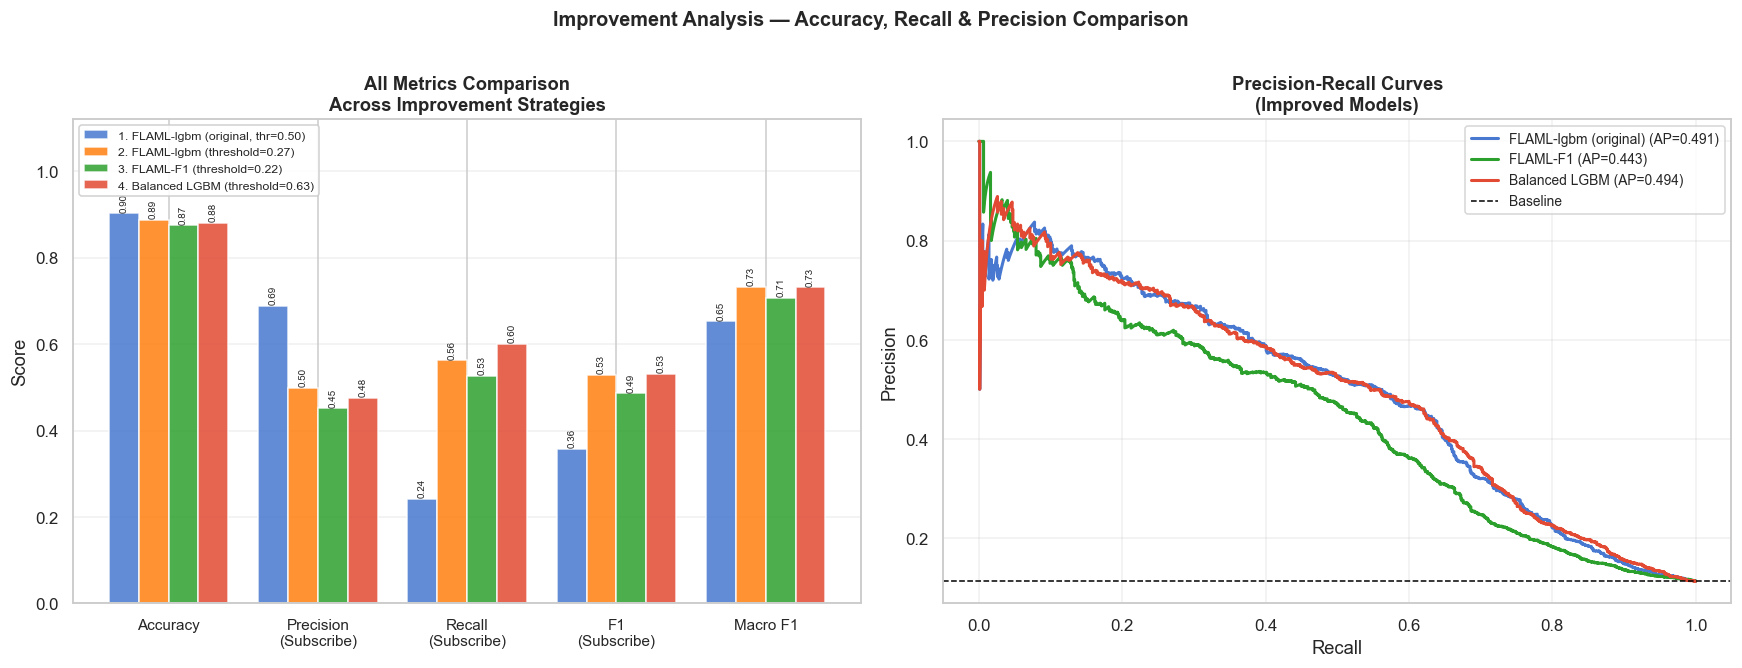

Chart saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/reports/improvement_comparison.png


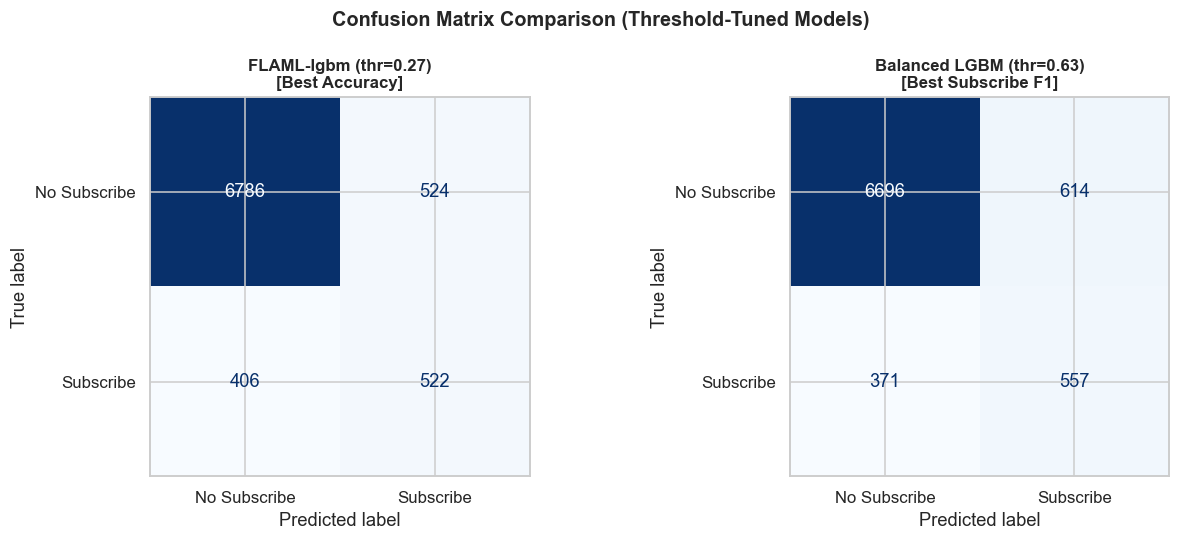

Saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/reports/confusion_matrix_comparison.png


In [42]:

# ═══════════════════════════════════════════════════════════════════════════════
# 9E — Final Comparison: All Improvement Strategies
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score as f1_score_fn

# Threshold-tuned FLAML predictions
y_pred_flaml_tuned = (y_proba_flaml >= OPTIMAL_THRESHOLD).astype(int)

# FLAML-F1 model with its own optimal threshold
prec_f1m, rec_f1m, thr_f1m = precision_recall_curve(y_test_int, y_proba_f1)
f1_f1m = 2 * prec_f1m[:-1] * rec_f1m[:-1] / (prec_f1m[:-1] + rec_f1m[:-1] + 1e-9)
opt_thr_f1m = float(thr_f1m[f1_f1m.argmax()])
y_pred_f1_tuned = (y_proba_f1 >= opt_thr_f1m).astype(int)

def full_metrics(y_true, y_pred, y_proba=None):
    return {
        "accuracy":            accuracy_score(y_true, y_pred),
        "subscribe_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "subscribe_recall":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "subscribe_f1":        f1_score_fn(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1":            f1_score_fn(y_true, y_pred, average="macro", zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba) if y_proba is not None else None,
        "roc_auc": roc_auc_score(y_true, y_proba) if y_proba is not None else None,
    }

all_strategies = {
    "1. FLAML-lgbm\n(original, thr=0.50)":           full_metrics(y_test_int, y_pred_flaml, y_proba_flaml),
    f"2. FLAML-lgbm\n(threshold={OPTIMAL_THRESHOLD:.2f})": full_metrics(y_test_int, y_pred_flaml_tuned, y_proba_flaml),
    f"3. FLAML-F1\n(threshold={opt_thr_f1m:.2f})":   full_metrics(y_test_int, y_pred_f1_tuned, y_proba_f1),
    f"4. Balanced LGBM\n(threshold={opt_thr_b:.2f})": full_metrics(y_test_int, y_pred_bal_tuned, y_proba_bal),
}

# Build comparison DataFrame
comp_rows = []
for name, m in all_strategies.items():
    comp_rows.append({
        "Strategy": name.replace("\n", " "),
        "Accuracy": m["accuracy"],
        "Precision\n(Subscribe)": m["subscribe_precision"],
        "Recall\n(Subscribe)": m["subscribe_recall"],
        "F1\n(Subscribe)": m["subscribe_f1"],
        "Macro F1": m["macro_f1"],
        "PR-AUC": m["pr_auc"],
        "ROC-AUC": m["roc_auc"],
    })
comp_df = pd.DataFrame(comp_rows)
print("📊 All Strategies Comparison:")
display(comp_df.style
    .highlight_max(subset=["Accuracy","Precision\n(Subscribe)","Recall\n(Subscribe)","F1\n(Subscribe)","Macro F1"], color="#c8e6c9")
    .format({c: "{:.4f}" for c in comp_df.columns if c != "Strategy"})
)

# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_plot = ["accuracy", "subscribe_precision", "subscribe_recall", "subscribe_f1", "macro_f1"]
metric_labels = ["Accuracy", "Precision\n(Subscribe)", "Recall\n(Subscribe)", "F1\n(Subscribe)", "Macro F1"]
colors_strat  = ["#4878CF", "#ff7f0e", "#2ca02c", "#E24A33"]
x_pos = np.arange(len(metrics_plot))
width_s = 0.2

ax = axes[0]
for i, (name, m) in enumerate(all_strategies.items()):
    values = [m[k] for k in metrics_plot]
    bars = ax.bar(x_pos + i * width_s, values, width=width_s,
                  label=name.replace("\n", " "), color=colors_strat[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x_pos + width_s * 1.5)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("All Metrics Comparison\nAcross Improvement Strategies", fontweight="bold")
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=6.5, padding=1, rotation=90)

# PR curves for all improved models
ax = axes[1]
model_probs = {
    "FLAML-lgbm (original)":   y_proba_flaml,
    f"FLAML-F1":               y_proba_f1,
    f"Balanced LGBM":          y_proba_bal,
}
colors_pr = ["#4878CF", "#2ca02c", "#E24A33"]
for color, (label, probs) in zip(colors_pr, model_probs.items()):
    p, r, _ = precision_recall_curve(y_test_int, probs)
    ap = average_precision_score(y_test_int, probs)
    ax.plot(r, p, color=color, lw=2, label=f"{label} (AP={ap:.3f})")

ax.axhline(y_test_int.mean(), color="black", linestyle="--", lw=1, label="Baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves\n(Improved Models)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("Improvement Analysis — Accuracy, Recall & Precision Comparison", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "improvement_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {REPORTS_DIR / 'improvement_comparison.png'}")

# ── Print the best confusion matrices side-by-side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, y_pred_c) in zip(axes, [
    (f"FLAML-lgbm (thr={OPTIMAL_THRESHOLD:.2f})\n[Best Accuracy]", y_pred_flaml_tuned),
    (f"Balanced LGBM (thr={opt_thr_b:.2f})\n[Best Subscribe F1]", y_pred_bal_tuned),
]):
    cm_c = confusion_matrix(y_test_int, y_pred_c)
    ConfusionMatrixDisplay(cm_c, display_labels=["No Subscribe", "Subscribe"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(title, fontweight="bold", fontsize=11)
plt.suptitle("Confusion Matrix Comparison (Threshold-Tuned Models)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {REPORTS_DIR / 'confusion_matrix_comparison.png'}")
